# Importing Required Libraries

In [58]:
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Audio specific packages
import librosa
from IPython.display import Audio, display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torch.optim as optim 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

from glob import glob
import random
from tqdm import tqdm
import soundfile as sf

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os

from sklearn.metrics import f1_score , accuracy_score, classification_report, confusion_matrix

device: cuda


# WandB setup

In [59]:
!pip install --upgrade wandb -q

In [60]:
import wandb
wandb.login()

True

# Train/Validation Data Loader

In [61]:
# creating a dataset class to use pre-created mel-spectrogram of audio mashup
class MelSpectrogramDataset(Dataset):
    def __init__(self, is_validation, train_paths,val_path):
        """
        is_validation: True for validation data
        train_paths: list of paths for training data
        val_path: Path to the root folder containing genre subfolders for validations
        """
        self.is_validation = is_validation
        self.train_paths = train_paths
        self.val_path = val_path
        self.genre_to_label = {
            "blues": 0, "classical": 1, "country": 2, "disco": 3, "hiphop": 4,
            "jazz": 5, "metal": 6, "pop": 7, "reggae": 8, "rock": 9
        }
        
        self.samples = []   

        if self.is_validation:
            for genre, label in self.genre_to_label.items():
                genre_path = os.path.join(val_path, genre, "*.npz")
                all_files = sorted(glob(genre_path))
                
                # Store pairs of (path, label)
                for f in all_files:
                    self.samples.append((f, label))
        else:
            for path in train_paths:
                for genre, label in self.genre_to_label.items():
                    genre_path = os.path.join(path, genre, "*.npz")
                    all_files = sorted(glob(genre_path))
                    
                    # Store pairs of (path, label)
                    for f in all_files:
                        self.samples.append((f, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file_path, label = self.samples[index]
        
        with np.load(file_path) as data:
            mel = data['mel_spectrogram']
            
        mel_tensor = torch.from_numpy(mel).float()
        mel_tensor = mel_tensor.unsqueeze(0)  #format channel, height, width
            
        return mel_tensor, torch.tensor(label, dtype=torch.long)

In [62]:
val_path = "/kaggle/input/data-generator-ipynb/train_data/"
train_paths = [
    "/kaggle/input/data-generator-2-ipynb/train_data/",
    "/kaggle/input/data-generator-3-ipynb/train_data/",
    "/kaggle/input/data-generator-4-ipynb/train_data/",
    "/kaggle/input/data-generator-5-ipynb/train_data/"
]

In [63]:
train_dataset = MelSpectrogramDataset(False, train_paths, val_path)
val_dataset = MelSpectrogramDataset(True, train_paths, val_path)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4,pin_memory=True)

# CNN 

In [64]:
class CNN_mashup_model(nn.Module):
    def __init__(self, layers, n, sr ,dr,fl):
        """
            layers: Number of CNN layer
            n: size of kernel 
            sr: sample rate of music 
            dr: dropout rate
            fl: number of start filters
        """
        super().__init__()
        self.layers = layers
        self.n = n
        self.sr = sr
        self.dr = dr

        self.input_norm = nn.BatchNorm2d(1)

        CNN_models = []
        self.prev_channel = 1 

        for i in range(self.layers):
            
            out_channels = min(fl * (2**i), 256)  # 256 did best
             
            CNN_models.extend([
                nn.Conv2d(in_channels=self.prev_channel, 
                          out_channels=out_channels, 
                          kernel_size=self.n, 
                          padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.Dropout(self.dr)
            ])
            self.prev_channel = out_channels

        self.CNN_model = nn.Sequential(*CNN_models)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(in_features=self.prev_channel, out_features=10)

    def forward(self,x):
        
        x = self.input_norm(x)

        x = self.CNN_model(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        return logits
    

In [65]:
def training_model(model, optimizer, train, val, epochs, patience, loss_fn):
   
    patience_counter = 0   # patience counter
    best_val = 0
    best_val_preds = []
    for e in tqdm(range(epochs)):
        if patience_counter > patience:
            print(f"Early stopping triggered at epoch {patience_counter}")
            break
        
        # training loop
        model.train()
        
        train_losses = []
        all_train_preds = []
        all_train_targets = []
        
        
        for i, (x, y ) in enumerate(train):
            
            x = x.to(device)
            y =  y.to(device)
    
            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds,y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            _, predicted_classes = torch.max(preds, 1) 
            all_train_preds.extend(predicted_classes.cpu().numpy())
            all_train_targets.extend(y.cpu().numpy())

        train_acc = accuracy_score(all_train_targets, all_train_preds)
        train_f1 = f1_score(all_train_targets, all_train_preds, average='macro')
        avg_train_loss = np.mean(train_losses)
            
        print(f"Epoch: {e}, Training_f1_macro: {train_f1}, Training_accuracy: {train_acc}, Avg_train_loss: {avg_train_loss}")

        # validation loop
        model.eval()
        
        all_val_preds = []
        all_val_targets = []
        
        with torch.inference_mode(): 
            for x, y  in val:
                
                x = x.to(device)
                y =  y.to(device)
                
                preds = model(x)
                
                _, predicted_classes = torch.max(preds, 1)
                all_val_preds.extend(predicted_classes.cpu().numpy())
                all_val_targets.extend(y.cpu().numpy())

        val_acc = accuracy_score(all_val_targets, all_val_preds)
        val_f1 = f1_score(all_val_targets, all_val_preds, average='macro')
        
        print(f"Epoch: {e}, validation_f1_macro: {val_f1}, validation_accuracy: {val_acc}")

        if val_f1 > best_val:
            best_val = val_f1
            patience_counter = 0 
            torch.save(model.state_dict(), "best_model.pth")
            best_val_preds = all_val_preds
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")
            
        # Log metrics to wandb
        wandb.log({
                    "train/accuracy": train_acc,
                    "train/f1_macro": train_f1,
                    "train/loss": avg_train_loss,
                    "val/accuracy": val_acc,
                    "val/f1_macro": val_f1,
                    "epoch": e
                })
  
    wandb.finish()
    model.load_state_dict(torch.load('best_model.pth'))

    print(classification_report(all_val_targets,best_val_preds))
    sns.heatmap(confusion_matrix(all_val_targets,best_val_preds) , annot=True,fmt='d', cmap='Blues' )
    plt.show()
    
    return model
    

In [66]:
# wandb setup
wandb.init(
    project="Audio_Mashup",
    group="Scratch_CNN",  
    name="layer_6_kernal_3_with_256_filters_end", 
    config={
        "architecture": "Scratch_CNN_with_6_layers",
        "epochs": 40,
        "lr": 0.001,
        "dropout": 0.2,
        "audio_sr": 22050,
        "patience":5,
        "start_filters":32
    }
)

In [67]:
model = CNN_mashup_model(6,3,22050,0.2,32)
model.to(device)

CNN_mashup_model(
  (input_norm): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (CNN_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

# Model traning

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch: 0, Training_f1_macro: 0.879481277199831, Training_accuracy: 0.8797960917587085, Avg_train_loss: 0.3416632684656297


  2%|▎         | 1/40 [06:13<4:03:03, 373.93s/it]

Epoch: 0, validation_f1_macro: 0.9149705360474851, validation_accuracy: 0.9154996600951734
Epoch: 1, Training_f1_macro: 0.9612219901405814, Training_accuracy: 0.961231945624469, Avg_train_loss: 0.11313422562341895


  5%|▌         | 2/40 [12:27<3:56:38, 373.66s/it]

...

Epoch: 22, validation_f1_macro: 0.9971099380435122, validation_accuracy: 0.9971108089734875
Patience: 5/5
Epoch: 23, Training_f1_macro: 0.998105422199149, Training_accuracy: 0.9981053525913339, Avg_train_loss: 0.005781843749222397


 60%|██████    | 24/40 [2:27:35<1:38:23, 368.99s/it]

Epoch: 23, validation_f1_macro: 0.9948431910673889, validation_accuracy: 0.9948334466349422
Patience: 6/5
Early stopping triggered at epoch 6


epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
train/accuracy,▁▆▇▇▇███████████████████
train/f1_macro,▁▆▇▇▇███████████████████
train/loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▆▂▃▆▇▇▇▇███▇████████▇██
val/f1_macro,▁▆▂▃▆▇▇▇▇███▇████████▇██
epoch,23
train/accuracy,0.99811
train/f1_macro,0.99811
train/loss,0.00578
val/accuracy,0.99483


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2942
           1       1.00      1.00      1.00      2942
           2       1.00      1.00      1.00      2942
           3       1.00      1.00      1.00      2942
           4       1.00      1.00      1.00      2942
           5       1.00      1.00      1.00      2942
           6       1.00      1.00      1.00      2942
           7       1.00      1.00      1.00      2942
           8       1.00      1.00      1.00      2942
           9       1.00      0.99      0.99      2942

    accuracy                           1.00     29420
   macro avg       1.00      1.00      1.00     29420
weighted avg       1.00      1.00      1.00     29420



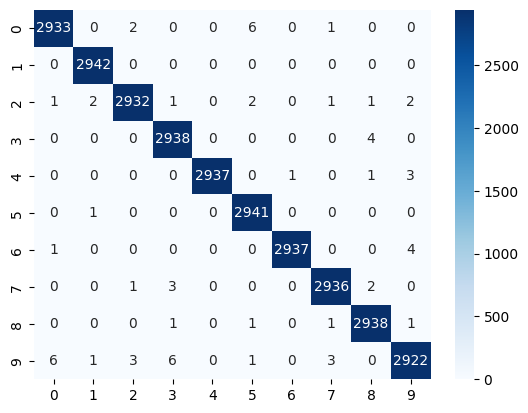

In [68]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
model_trained = training_model(model, optimizer, train_loader, val_loader, 40, 5, loss_fn )

# Test data loader

In [69]:
class test_mashed_dataset(Dataset):
    def __init__(self, path, test_csv, sr, duration):
        self.path = path
        self.test_csv = test_csv
        self.sr = sr
        self.duration = duration
        self.num_samples = int(duration * sr)

        # Mel transform
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr, n_fft=2048, hop_length=512, n_mels=64
        )
        self.db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.test_csv)

    def __getitem__(self,index):
        filename = test_csv.iloc[index][0]
        path = self.path+filename
        
        """Load and preprocess audio."""
        audio, sr = torchaudio.load(path)
        
        if sr != self.sr:         # correct sample rate
            audio = torchaudio.functional.resample(audio, sr, self.sr)
        
            
        if audio.shape[0] > 1:    # ensure mono audio
            audio = audio.mean(0, keepdim=True)

        if audio.shape[1] > self.num_samples:
            audio = audio[:, :self.num_samples]
        
        if audio.shape[1] < self.num_samples:
            audio = torch.nn.functional.pad(audio, (0, self.num_samples - audio.shape[1]))

        mel = self.mel(audio)
        mel_db = self.db(mel)

        # mel_tensor = mel_db.unsqueeze(0)  #format channel, height, width

        return mel_db
        

In [70]:
test_csv = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv" , index_col='id')
sample_submission = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv" , index_col='id' )
path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/"

In [71]:
test_data = test_mashed_dataset(path, test_csv, 22050, 30)
test_loader = DataLoader(test_data , batch_size=124, shuffle=False, num_workers=4,pin_memory=True)

In [72]:
def prediction(model,test_loader):
    model.eval()
    predictions = []
    with torch.inference_mode():
        for x in tqdm(test_loader):
            x = x.to(device)
            logits = model(x)
            
            _, predicted_classes = torch.max(logits, 1)
            predictions.extend(predicted_classes.cpu().numpy())
            
    return predictions

In [73]:
label_to_genre = {
    0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
    5: "jazz", 6: "metal", 7: "pop", 8: "reggae", 9: "rock"
}

# Final prediction on test data

In [74]:
preds = prediction(model_trained,test_loader)
sample_submission['genre'] = [label_to_genre[i] for i in preds]

100%|██████████| 25/25 [01:02<00:00,  2.51s/it]


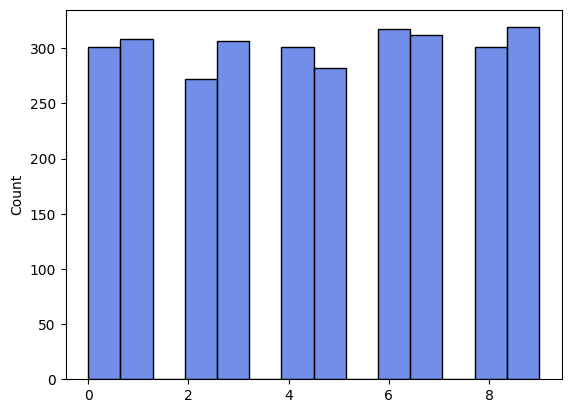

In [75]:
sns.histplot(preds,color="royalblue")
plt.show()
sample_submission.to_csv("submission.csv")

In [77]:
import kagglehub

MODEL_UPLOAD_DIR = "/kaggle/working/Scratch_CNN" 
os.makedirs(MODEL_UPLOAD_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(MODEL_UPLOAD_DIR, "Scratch_CNN.pth")
torch.save(model.state_dict(), MODEL_SAVE_PATH)     # model_trained
print(f"Model saved to {MODEL_SAVE_PATH}")

KAGGLE_USERNAME = 'aryanchauhan97971234' 
MODEL = 'Scratch_CNN_3_final'
FRAMEWORK = 'pytorch'
VARIATION = '6_3_22050_0.2_32'

handle = f'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}'

print(f"Uploading model from {MODEL_UPLOAD_DIR} to {handle}...")

kagglehub.model_upload(
    handle,                     
    MODEL_UPLOAD_DIR,           
    license_name="Apache 2.0", 
    version_notes="4th run with transfer, lr scheduler"
)
print("Upload complete!")

Model saved to /kaggle/working/Scratch_CNN/Scratch_CNN.pth
Uploading model from /kaggle/working/Scratch_CNN to aryanchauhan97971234/Scratch_CNN_3_final/pytorch/6_3_22050_0.2_32...
Uploading Model https://api.kaggle.com/models/aryanchauhan97971234/Scratch_CNN_3_final/pytorch/6_3_22050_0.2_32 ...
Model 'Scratch_CNN_3_final' does not exist or access is forbidden for user 'aryanchauhan97971234'. Creating or handling Model...
Model 'Scratch_CNN_3_final' Created.
Starting upload for file /kaggle/working/Scratch_CNN/Scratch_CNN.pth


Uploading: 100%|██████████| 6.32M/6.32M [00:02<00:00, 3.16MB/s]

Upload successful: /kaggle/working/Scratch_CNN/Scratch_CNN.pth (6MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/aryanchauhan97971234/Scratch_CNN_3_final/pytorch/6_3_22050_0.2_32
Upload complete!
